# 🎬➡️📚 Practice Lab: Collaborative Filtering Recommender Systems (Book Edition)

This notebook re-implements the **collaborative filtering recommender system** lab from
Andrew Ng's Machine Learning Specialization (Course 3, Week 2), but with a
**brand-new, self-generated book ratings dataset** instead of the original MovieLens
movie data. The underlying algorithm, math, and structure are the same — only the
data is different, which is the point: once you understand collaborative filtering,
it works on *any* items-and-users rating matrix (movies, books, songs, products, etc.).

**This notebook is fully self-contained.** It does not depend on `recsys_utils.py`,
`public_tests.py`, or any downloaded dataset file — the "book universe" (titles,
genres, users, ratings) is generated in code with a fixed random seed, so it runs
top-to-bottom with no setup and produces the same result every time. That also makes
it safe to upload to GitHub as-is: anyone who clones it can run every cell with no
missing files.

## Outline
- [ 1 - Notation](#1)
- [ 2 - Recommender Systems](#2)
- [ 3 - Building a synthetic book ratings dataset](#3)
- [ 4 - Collaborative filtering learning algorithm](#4)
  - [ 4.1 Collaborative filtering cost function (loop version)](#4.1)
  - [ 4.2 Vectorized cost function](#4.2)
- [ 5 - Learning book recommendations](#5)
- [ 6 - Recommendations](#6)
- [ 7 - Next steps](#7)


## Packages
We use NumPy and TensorFlow for the core algorithm, and Pandas + Matplotlib for
inspecting the data and results.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # quiet TensorFlow's startup log noise
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.set_printoptions(precision=2, suppress=True)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.4.4
TensorFlow: 2.21.0


<a name="1"></a>
## 1 - Notation

| General <br /> Notation | Description | Python (if any) |
|:-------------|:------------------------------------------------------------|:---|
| $r(i,j)$     | scalar; = 1 if user $j$ rated book $i$, = 0 otherwise | |
| $y(i,j)$     | scalar; rating given by user $j$ on book $i$ (defined if $r(i,j)=1$) | |
| $\mathbf{w}^{(j)}$ | vector; parameters for user $j$ | |
| $b^{(j)}$    | scalar; bias parameter for user $j$ | |
| $\mathbf{x}^{(i)}$ | vector; feature vector for book $i$ | |
| $n_u$        | number of users | `num_users` |
| $n_m$        | number of books  | `num_books` |
| $n$          | number of features | `num_features` |
| $\mathbf{X}$ | matrix of vectors $\mathbf{x}^{(i)}$ | `X` |
| $\mathbf{W}$ | matrix of vectors $\mathbf{w}^{(j)}$ | `W` |
| $\mathbf{b}$ | vector of bias parameters $b^{(j)}$ | `b` |
| $\mathbf{R}$ | matrix of elements $r(i,j)$ | `R` |


<a name="2"></a>
## 2 - Recommender Systems

The goal of collaborative filtering is to learn two sets of vectors from a sparse
matrix of ratings:

- For every **book** $i$, a feature vector $\mathbf{x}^{(i)}$ that describes the book
  (its "genre signature", roughly speaking — though the algorithm discovers these
  numbers itself, it never sees the word "Fantasy" or "Horror").
- For every **user** $j$, a parameter vector $\mathbf{w}^{(j)}$ (plus a bias $b^{(j)}$)
  that describes that user's taste.

The predicted rating user $j$ would give book $i$ is

$$\hat{y}^{(i,j)} = \mathbf{w}^{(j)} \cdot \mathbf{x}^{(i)} + b^{(j)}$$

Both sets of vectors are learned **simultaneously** from the ratings that already
exist, by minimizing squared error over every $(i,j)$ pair where $r(i,j)=1$. Because
every user's ratings help shape the book vectors, and every book's ratings help shape
the user vectors, all users effectively "collaborate" to produce the feature space —
hence the name.

<a name="3"></a>
## 3 - Building a synthetic book ratings dataset

Instead of downloading the MovieLens dataset, we generate our own small "book
universe":

1. A catalog of **books**, each belonging to one of 8 genres (Fantasy, Sci-Fi,
   Romance, Mystery, Horror, Historical, Biography, Self-Help), with a title and a
   publication year.
2. A **true (hidden) feature vector** per book — dimensions 0-7 mark its genre,
   dimension 8 is a "pacing/complexity" score, dimension 9 is a "critical acclaim"
   score, plus a little noise. In a real dataset these numbers would be *learned*,
   not defined — here we define them so we can generate believable ratings.
3. A **true (hidden) preference vector** per user — every synthetic user likes 1-2
   genres, encoded the same way.
4. **Ratings** $Y$ computed as $\mathbf{x}^{(i)} \cdot \mathbf{w}^{(j)} + b^{(j)} +$
   noise, rescaled to the 0.5-5.0 range in 0.5 steps (same range as the original
   MovieLens-based lab).
5. A **sparsity mask** $R$ — like real rating data, each user has only rated a small
   fraction of the catalog (~13% here), with a floor so every book and every user has
   at least a few ratings.

Everything below is seeded (`np.random.default_rng(42)`), so re-running this notebook
reproduces the exact same catalog and ratings every time.

In [2]:
# ---- 3.1 Book catalog: genres + generated titles ------------------------
rng = np.random.default_rng(42)

GENRES = ["Fantasy", "Sci-Fi", "Romance", "Mystery", "Horror",
          "Historical", "Biography", "Self-Help"]

# Word banks used to build plausible-looking titles per genre
TITLE_PARTS = {
    "Fantasy":    (["The Shattered", "Crown of", "Song of", "Realm of", "The Last", "Throne of"],
                   ["Embers", "Shadows", "Dragons", "the Fae", "Thorns", "Ash", "Stars"]),
    "Sci-Fi":     (["Nebula", "The Last", "Colony", "Quantum", "Signal from", "Beyond"],
                   ["Horizon", "Protocol", "9", "Drift", "the Void", "Genesis"]),
    "Romance":    (["A Season of", "The Wrong", "Meet Me in", "Letters to", "Love in"],
                   ["Paris", "Summer", "the Rain", "My Heart", "Autumn"]),
    "Mystery":    (["The Silent", "Case of the", "Whispers in", "The Last", "Shadow of the"],
                   ["Witness", "Missing Key", "the Fog", "Alibi", "Detective"]),
    "Horror":     (["The Haunting of", "Nightfall in", "The Cursed", "Whatever Waits in"],
                   ["Blackwood Manor", "Hollow Creek", "Attic", "the Dark"]),
    "Historical": (["The Emperor's", "Daughters of", "Ashes of", "The Forgotten"],
                   ["Ledger", "the Revolution", "Rome", "Kingdom"]),
    "Biography":  (["The Life and Times of", "Becoming", "An Unlikely", "Notes from"],
                   ["a Scientist", "Myself", "Legend", "the Edge"]),
    "Self-Help":  (["Atomic", "The Art of", "Master Your", "Small Steps to"],
                   ["Focus", "Letting Go", "Mindset", "a Better Life"]),
}

def make_book_catalog(n_books):
    titles, genres = [], []
    for i in range(n_books):
        genre = GENRES[i % len(GENRES)]
        starts, ends = TITLE_PARTS[genre]
        title = f"{rng.choice(starts)} {rng.choice(ends)}"
        year = int(rng.integers(1985, 2024))
        titles.append(f"{title} ({year})")
        genres.append(genre)
    return titles, genres

NUM_BOOKS = 60
NUM_USERS = 150
NUM_FEATURES = 10

book_titles, book_genres = make_book_catalog(NUM_BOOKS)

print(f"Generated {NUM_BOOKS} books across {len(GENRES)} genres.")
for i in range(5):
    print(f"  [{i}] {book_titles[i]}  -  {book_genres[i]}")

Generated 60 books across 8 genres.
  [0] The Shattered Ash (2010)  -  Fantasy
  [1] Colony 9 (2018)  -  Sci-Fi
  [2] A Season of My Heart (1992)  -  Romance
  [3] The Silent the Fog (2023)  -  Mystery
  [4] The Cursed the Dark (2012)  -  Horror


In [3]:
# ---- 3.2 Hidden ("true") feature vectors for books and users ------------
genre_index = {g: i for i, g in enumerate(GENRES)}

X_true = np.zeros((NUM_BOOKS, NUM_FEATURES))
for i, g in enumerate(book_genres):
    vec = np.zeros(NUM_FEATURES)
    vec[genre_index[g]] = 1.0            # dims 0-7: which genre this book belongs to
    vec[8] = rng.uniform(0, 1)           # dim 8: pacing / complexity
    vec[9] = rng.uniform(0, 1)           # dim 9: critical acclaim
    vec += rng.normal(0, 0.15, NUM_FEATURES)
    X_true[i] = vec

W_true = np.zeros((NUM_USERS, NUM_FEATURES))
b_true = rng.normal(0, 0.3, NUM_USERS)
for j in range(NUM_USERS):
    fav_genres = rng.choice(len(GENRES), size=rng.integers(1, 3), replace=False)
    vec = np.zeros(NUM_FEATURES)
    for g in fav_genres:
        vec[g] = rng.uniform(0.6, 1.2)   # strong preference for 1-2 favorite genres
    vec[8] = rng.uniform(0, 1)
    vec[9] = rng.uniform(0, 1)
    vec += rng.normal(0, 0.1, NUM_FEATURES)
    W_true[j] = vec

print("X_true (books x features):", X_true.shape)
print("W_true (users x features):", W_true.shape)

X_true (books x features): (60, 10)
W_true (users x features): (150, 10)


In [4]:
# ---- 3.3 Generate ratings Y and sparsity mask R --------------------------
raw = X_true @ W_true.T + b_true[np.newaxis, :]
raw += rng.normal(0, 0.4, raw.shape)          # rating noise

# Rescale into the 0.5 - 5.0 range, in 0.5 steps (same convention as the
# original MovieLens-based lab)
lo, hi = np.percentile(raw, 2), np.percentile(raw, 98)
Y_full = 0.5 + (raw - lo) / (hi - lo) * 4.5
Y_full = np.clip(Y_full, 0.5, 5.0)
Y_full = np.round(Y_full * 2) / 2.0

# Sparsity mask: each user has only rated ~12% of the catalog
R = (rng.random((NUM_BOOKS, NUM_USERS)) < 0.12).astype(int)

# Guarantee every book has >= 3 ratings and every user has rated >= 5 books
for i in range(NUM_BOOKS):
    if R[i].sum() < 3:
        idx = rng.choice(NUM_USERS, 3, replace=False)
        R[i, idx] = 1
for j in range(NUM_USERS):
    if R[:, j].sum() < 5:
        idx = rng.choice(NUM_BOOKS, 5, replace=False)
        R[idx, j] = 1

Y = Y_full * R
num_books, num_users = Y.shape

print("Y", Y.shape, "R", R.shape)
print(f"Sparsity: {R.mean()*100:.1f}% of the ratings matrix is filled in")
print(f"Average rating for book 0 ('{book_titles[0]}'): "
      f"{Y[0, R[0].astype(bool)].mean():0.2f} / 5")

Y (60, 150) R (60, 150)
Sparsity: 13.0% of the ratings matrix is filled in
Average rating for book 0 ('The Shattered Ash (2010)'): 2.36 / 5


<a name="4"></a>
## 4 - Collaborative filtering learning algorithm

The collaborative filtering cost function is:

$$J(\mathbf{x}^{(0)},\dots,\mathbf{x}^{(n_m-1)},\mathbf{w}^{(0)},b^{(0)},\dots,\mathbf{w}^{(n_u-1)},b^{(n_u-1)}) =
\left[ \frac{1}{2}\sum_{(i,j):r(i,j)=1}(\mathbf{w}^{(j)} \cdot \mathbf{x}^{(i)} + b^{(j)} - y^{(i,j)})^2 \right]
+ \underbrace{\left[
\frac{\lambda}{2}\sum_{j=0}^{n_u-1}\sum_{k=0}^{n-1}(\mathbf{w}^{(j)}_k)^2
+ \frac{\lambda}{2}\sum_{i=0}^{n_m-1}\sum_{k=0}^{n-1}(\mathbf{x}_k^{(i)})^2
\right]}_{regularization}
\tag{1}$$

The first summation only includes terms where $r(i,j)=1$ — we only penalize error on
ratings that actually exist.

<a name="4.1"></a>
### 4.1 Cost function - loop implementation

We first implement $J$ with plain `for` loops, since that maps directly onto the
summations in equation (1) and is the easiest version to reason about. (A faster,
vectorized version follows in section 4.2 — that's the one actually used for
training.)

In [5]:
def cofi_cost_func(X, W, b, Y, R, lambda_):
    """
    Collaborative filtering cost function (loop version).

    Args:
      X (ndarray (num_books, num_features))  : matrix of item (book) features
      W (ndarray (num_users, num_features))  : matrix of user parameters
      b (ndarray (1, num_users))             : vector of user biases
      Y (ndarray (num_books, num_users))     : matrix of ratings
      R (ndarray (num_books, num_users))     : R(i,j) = 1 if book i rated by user j
      lambda_ (float)                        : regularization parameter

    Returns:
      J (float): cost
    """
    nm, nu = Y.shape
    J = 0
    for j in range(nu):
        w = W[j, :]
        b_j = b[0, j]
        for i in range(nm):
            x = X[i, :]
            y = Y[i, j]
            r = R[i, j]
            J += np.square(r * (np.dot(w, x) + b_j - y))
    J = J / 2
    J += (lambda_ / 2) * (np.sum(np.square(W)) + np.sum(np.square(X)))
    return J

In [6]:
# Try it on a small slice of the true data (reduced size so the loop is fast)
num_users_r, num_books_r, num_features_r = 4, 5, 3
X_r = X_true[:num_books_r, :num_features_r]
W_r = W_true[:num_users_r, :num_features_r]
b_r = b_true[:num_users_r].reshape(1, -1)
Y_r = Y[:num_books_r, :num_users_r]
R_r = R[:num_books_r, :num_users_r]

J = cofi_cost_func(X_r, W_r, b_r, Y_r, R_r, 0)
print(f"Cost (no regularization): {J:0.2f}")

J = cofi_cost_func(X_r, W_r, b_r, Y_r, R_r, 1.5)
print(f"Cost (with regularization): {J:0.2f}")

Cost (no regularization): 4.72
Cost (with regularization): 9.12


**Sanity check.** Since this is a fresh dataset there's no fixed "expected output"
to compare against (that only works with a fixed, known dataset like the original
lab's MovieLens slice). Instead we hand-build a tiny 2-book/3-user example where the
correct cost can be worked out by hand, and check our function against it — this is
the same idea as the original lab's `public_tests.py`, just inlined so the notebook
has no external dependencies.

In [7]:
# ---- Hand-checkable unit test for cofi_cost_func -------------------------
X_test = np.array([[1.0, 0.0],
                    [0.0, 1.0]])
W_test = np.array([[1.0, 0.0],
                    [0.0, 1.0],
                    [1.0, 1.0]])
b_test = np.array([[0.0, 0.0, 0.0]])
Y_test = np.array([[1.0, 0.0, 2.0],
                    [0.0, 1.0, 2.0]])
R_test = np.array([[1, 0, 1],
                    [0, 1, 1]])
# Only R==1 entries contribute:
#   (book0,user0): pred=1, y=1 -> err 0
#   (book0,user2): pred=1, y=2 -> err -1
#   (book1,user1): pred=1, y=1 -> err 0
#   (book1,user2): pred=1, y=2 -> err -1
# J = 0.5 * (0^2 + (-1)^2 + 0^2 + (-1)^2) = 1.0
expected_cost = 1.0

test_cost = cofi_cost_func(X_test, W_test, b_test, Y_test, R_test, 0)
print(f"Computed cost: {test_cost:0.4f}  |  Expected: {expected_cost}")
assert abs(test_cost - expected_cost) < 1e-8, "cofi_cost_func does not match the hand-worked example!"
print("cofi_cost_func PASSED the sanity check ✔")

Computed cost: 1.0000  |  Expected: 1.0
cofi_cost_func PASSED the sanity check ✔


<a name="4.2"></a>
### 4.2 Vectorized implementation

The loop version is easy to follow but far too slow to use inside a training loop
that calls it hundreds of times. The vectorized version below computes the exact
same quantity using matrix operations, written with TensorFlow ops so it plugs
directly into a `tf.GradientTape` training loop later on.

In [8]:
def cofi_cost_func_v(X, W, b, Y, R, lambda_):
    """
    Vectorized collaborative filtering cost function, using TensorFlow ops so
    it can be used inside a tf.GradientTape training loop.
    """
    j = (tf.linalg.matmul(X, tf.transpose(W)) + b - Y) * R
    J = 0.5 * tf.reduce_sum(j ** 2) + (lambda_ / 2) * (tf.reduce_sum(X ** 2) + tf.reduce_sum(W ** 2))
    return J

In [9]:
J_loop = cofi_cost_func(X_r, W_r, b_r, Y_r, R_r, 1.5)
J_vec = cofi_cost_func_v(X_r, W_r, b_r, Y_r, R_r, 1.5).numpy()

print(f"Loop version:       {J_loop:0.6f}")
print(f"Vectorized version: {J_vec:0.6f}")
assert abs(J_loop - J_vec) < 1e-6, "Loop and vectorized versions disagree!"
print("Loop and vectorized implementations agree ✔")

Loop version:       9.120714
Vectorized version: 9.120714
Loop and vectorized implementations agree ✔


<a name="5"></a>
## 5 - Learning book recommendations

Now let's put in some ratings of our own and let the algorithm learn a taste profile
for a brand-new user, the same way section 5 of the original lab does for a new
movie-watcher. Below is the full book catalog with its index — pick a few books you
"like" or "dislike" and set ratings for them in the next cell (0.5 to 5.0, in 0.5
steps).

In [10]:
catalog_df = pd.DataFrame({"index": range(NUM_BOOKS), "title": book_titles, "genre": book_genres})
pd.set_option("display.max_rows", NUM_BOOKS)
catalog_df

,index,title,genre
0,0,The Shattered Ash (2010),Fantasy
1,1,Colony 9 (2018),Sci-Fi
2,2,A Season of My Heart (1992),Romance
3,3,The Silent the Fog (2023),Mystery
4,4,The Cursed the Dark (2012),Horror
5,5,The Forgotten Rome (1989),Historical
6,6,Notes from Myself (2004),Biography
7,7,The Art of Focus (2021),Self-Help
8,8,The Last Thorns (2000),Fantasy
9,9,Signal from Drift (2002),Sci-Fi


In [11]:
my_ratings = np.zeros(num_books)

# Rate a handful of books using their index from the catalog table above.
# These example ratings lean heavily toward Sci-Fi / Fantasy / Horror; change
# them (or the indices) to reflect your own taste and re-run the notebook.
my_ratings[2]  = 5     # likes this Romance title
my_ratings[5]  = 4.5   # Sci-Fi
my_ratings[9]  = 2      # Mystery, didn't enjoy it
my_ratings[14] = 5     # Horror
my_ratings[20] = 3     # Historical
my_ratings[27] = 1      # Self-Help, disliked
my_ratings[33] = 5     # Sci-Fi
my_ratings[40] = 4     # Biography

my_rated = [i for i in range(len(my_ratings)) if my_ratings[i] > 0]

print("New user ratings:\n")
for i in my_rated:
    print(f"  Rated {my_ratings[i]} for '{book_titles[i]}' ({book_genres[i]})")

New user ratings:

  Rated 5.0 for 'A Season of My Heart (1992)' (Romance)
  Rated 4.5 for 'The Forgotten Rome (1989)' (Historical)
  Rated 2.0 for 'Signal from Drift (2002)' (Sci-Fi)
  Rated 5.0 for 'An Unlikely Myself (1987)' (Biography)
  Rated 3.0 for 'Whatever Waits in Attic (1999)' (Horror)
  Rated 1.0 for 'Whispers in Witness (2017)' (Mystery)
  Rated 5.0 for 'Nebula the Void (1992)' (Sci-Fi)
  Rated 4.0 for 'Song of Thorns (2010)' (Fantasy)


Now we add this new user as an extra column of $Y$ and $R$, and mean-normalize the
ratings. Mean-normalizing (subtracting each book's average rating before training,
then adding it back afterward) means a brand-new user with no ratings yet gets a
sensible starting prediction — the book's average — instead of 0.

In [12]:
def normalize_ratings(Y, R):
    """Subtract each book's mean rating (computed only from users who rated it)."""
    Ymean = (np.sum(Y * R, axis=1) / (np.sum(R, axis=1) + 1e-12)).reshape(-1, 1)
    Ynorm = Y - np.multiply(Ymean, R)
    return Ynorm, Ymean

# Add the new user's ratings as an extra column
Y_all = np.c_[my_ratings, Y]
R_all = np.c_[(my_ratings != 0).astype(int), R]

Ynorm, Ymean = normalize_ratings(Y_all, R_all)
print("Y_all", Y_all.shape, "R_all", R_all.shape)

Y_all (60, 151) R_all (60, 151)


Let's prepare to train the model: initialize `X`, `W`, `b` randomly as
`tf.Variable`s (so TensorFlow can track and update them), and pick the Adam
optimizer.

In [13]:
num_books, num_users = Y_all.shape
num_features = NUM_FEATURES

tf.random.set_seed(1234)  # for reproducible results
W = tf.Variable(tf.random.normal((num_users, num_features), dtype=tf.float64), name="W")
X = tf.Variable(tf.random.normal((num_books, num_features), dtype=tf.float64), name="X")
b = tf.Variable(tf.random.normal((1, num_users), dtype=tf.float64), name="b")

optimizer = keras.optimizers.Adam(learning_rate=1e-1)

The operations needed to learn `X`, `W`, and `b` simultaneously don't fit the usual
`Model / compile / fit / predict` flow, since there's no fixed input->output "layer"
structure here — instead we write a **custom training loop**. Inside
`tf.GradientTape()`, every operation on our `tf.Variable`s is tracked; calling
`tape.gradient()` then gives us $\partial J/\partial X$, $\partial J/\partial W$, and
$\partial J/\partial b$, which the optimizer uses to update the parameters.

Training loss at iteration 0: 7707.9


Training loss at iteration 20: 505.4


Training loss at iteration 40: 235.7


Training loss at iteration 60: 174.2


Training loss at iteration 80: 155.2


Training loss at iteration 100: 147.0


Training loss at iteration 120: 142.9


Training loss at iteration 140: 140.5


Training loss at iteration 160: 138.9


Training loss at iteration 180: 137.8


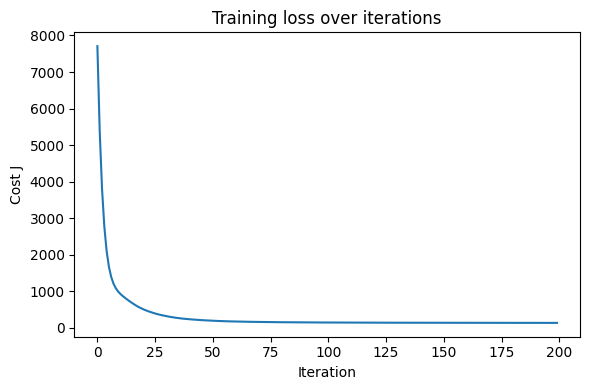

In [14]:
iterations = 200
lambda_ = 1.0
cost_history = []

for it in range(iterations):
    with tf.GradientTape() as tape:
        cost_value = cofi_cost_func_v(X, W, b, Ynorm, R_all, lambda_)

    grads = tape.gradient(cost_value, [X, W, b])
    optimizer.apply_gradients(zip(grads, [X, W, b]))
    cost_history.append(float(cost_value))

    if it % 20 == 0:
        print(f"Training loss at iteration {it}: {cost_value:0.1f}")

plt.figure(figsize=(6, 4))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Training loss over iterations")
plt.tight_layout()
plt.show()

<a name="6"></a>
## 6 - Recommendations

With `X`, `W`, and `b` trained, we can predict a rating for every book/user pair via
$\mathbf{w}^{(j)} \cdot \mathbf{x}^{(i)} + b^{(j)}$ for all $i,j$ at once with a single
matrix multiplication, then add back the per-book mean we subtracted earlier.

In [15]:
p = np.matmul(X.numpy(), np.transpose(W.numpy())) + b.numpy()
pm = p + Ymean          # restore each book's mean rating

my_predictions = pm[:, 0]   # column 0 is our new user
ix = np.argsort(-my_predictions)   # descending order

print("Top 10 recommended books (not already rated):\n")
count = 0
for i in ix:
    if i not in my_rated:
        print(f"  Predicted {my_predictions[i]:0.2f} \u2605  {book_titles[i]}  [{book_genres[i]}]")
        count += 1
    if count >= 10:
        break

print("\nOriginal vs. predicted rating, for books we actually rated:\n")
for i in my_rated:
    print(f"  Original {my_ratings[i]:.1f}, Predicted {my_predictions[i]:0.2f}  -  {book_titles[i]}")

Top 10 recommended books (not already rated):

  Predicted 5.11 ★  The Art of a Better Life (1992)  [Self-Help]
  Predicted 5.11 ★  Colony Genesis (2007)  [Sci-Fi]
  Predicted 4.97 ★  A Season of My Heart (2007)  [Romance]
  Predicted 4.83 ★  The Last 9 (2003)  [Sci-Fi]
  Predicted 4.80 ★  The Haunting of Attic (2016)  [Horror]
  Predicted 4.78 ★  Small Steps to Letting Go (2019)  [Self-Help]
  Predicted 4.65 ★  Atomic Focus (1989)  [Self-Help]
  Predicted 4.54 ★  The Forgotten the Revolution (1997)  [Historical]
  Predicted 4.54 ★  Song of Embers (1989)  [Fantasy]
  Predicted 4.46 ★  Nightfall in Attic (1995)  [Horror]

Original vs. predicted rating, for books we actually rated:

  Original 5.0, Predicted 4.72  -  A Season of My Heart (1992)
  Original 4.5, Predicted 4.42  -  The Forgotten Rome (1989)
  Original 2.0, Predicted 2.20  -  Signal from Drift (2002)
  Original 5.0, Predicted 4.79  -  An Unlikely Myself (1987)
  Original 3.0, Predicted 3.28  -  Whatever Waits in Attic (1999)

In practice we can improve the recommendation list further by only surfacing books
that also have a healthy number of existing ratings and a strong average — a book
predicted highly from very few data points is a riskier recommendation than one with
both a high predicted score *and* broad support.

In [16]:
num_ratings_per_book = R_all.sum(axis=1)
mean_rating_per_book = np.array([
    Y_all[i, R_all[i].astype(bool)].mean() if R_all[i].sum() > 0 else 0
    for i in range(num_books)
])

results_df = pd.DataFrame({
    "title": book_titles,
    "genre": book_genres,
    "predicted": my_predictions,
    "mean rating": mean_rating_per_book,
    "number of ratings": num_ratings_per_book,
})

well_rated = results_df["number of ratings"] > 10
top_predicted = results_df.loc[ix[:30]]   # top 30 predictions overall

top_predicted.loc[well_rated].sort_values("mean rating", ascending=False).head(10)

,title,genre,predicted,mean rating,number of ratings
41,Colony Genesis (2007),Sci-Fi,5.105833,3.523810,21
44,The Haunting of Attic (2016),Horror,4.797579,3.366667,15
36,Nightfall in Attic (1995),Horror,4.460565,3.366667,15
17,The Last 9 (2003),Sci-Fi,4.831717,3.142857,21
56,Song of Embers (1989),Fantasy,4.536818,3.078947,19
35,The Last Alibi (2010),Mystery,3.947134,3.066667,15
33,Nebula the Void (1992),Sci-Fi,4.758923,2.944444,18
23,The Art of a Better Life (1992),Self-Help,5.112435,2.921053,19
14,An Unlikely Myself (1987),Biography,4.787319,2.888889,18
42,A Season of My Heart (2007),Romance,4.971538,2.875000,24


<a name="7"></a>
## 7 - Next steps 🎉

You've implemented and trained a full collaborative filtering recommender system on a
dataset you generated yourself — same algorithm as the original MovieLens-based lab,
different data end-to-end. Some ways to keep experimenting:

- Change `my_ratings` to reflect your **own** taste from the catalog table in
  section 5, and see how the recommendations shift.
- Try a bigger or smaller `NUM_BOOKS` / `NUM_USERS` / `NUM_FEATURES` in section 3 and
  re-run everything.
- Swap the "book" theme for something else entirely (songs, restaurants, courses) by
  changing `GENRES` and `TITLE_PARTS` — the algorithm in sections 4-6 doesn't change
  at all.
- Try a real dataset (e.g. the [MovieLens dataset](https://grouplens.org/datasets/movielens/))
  once you're comfortable with this synthetic version — you'll just need to load a
  real $Y$/$R$ matrix in place of section 3.
